# Decision Tree vs Random Forest — Public Dataset + Cross-Validation + GridSearchCV

## Real public dataset

We will use the **Breast Cancer Wisconsin (Diagnostic)** dataset.

It is a well-known public classification dataset containing measurements computed from digitized images of breast-mass cell nuclei.

Our target is:

- `0` → malignant
- `1` → benign

This is a good teaching dataset because it is:
- already numerical
- large enough for train/test + cross-validation
- suitable for Decision Trees and Random Forests
- simple enough that we don't need a complicated preprocessing pipeline

> **Important:** This notebook is for learning the ML workflow, not for building a medical diagnostic system.


In [21]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("\nTarget names:", data.target_names)
print("\nClass counts:")
print(y.value_counts())

X.head()

Dataset shape: (569, 30)

Target names: ['malignant' 'benign']

Class counts:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## What are the features?

There are 30 numerical features, such as:

- mean radius
- mean texture
- mean perimeter
- mean area
- worst radius
- worst texture
- worst perimeter

The model will learn a relationship between these measurements and the target.

No scaling is required for Decision Trees or Random Forests.


In [22]:
print("Number of features:", X.shape[1])
print("\nFeature names:")
print(list(X.columns))

print("\nMissing values:")
print(X.isna().sum().sum())

Number of features: 30

Feature names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Missing values:
0


# 1. Train/Test Split

We keep the test set completely untouched while selecting hyperparameters.

```text
Full public dataset
       ↓
Train 80%        Test 20%
   ↓
5-fold CV
   ↓
choose hyperparameters
   ↓
final model
   ↓
Test ONCE
```

The **5-fold CV happens only inside the training data**.


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 455
Test rows: 114


# 2. First: one Decision Tree baseline

Before GridSearchCV, train one simple tree.

This gives students a reference point.

Then we will ask:

> “Can we improve it by changing hyperparameters?”


In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_baseline = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_baseline.fit(X_train, y_train)

print("Baseline Decision Tree trained.")

Baseline Decision Tree trained.


# 3. Why Cross-Validation?

Suppose we use only one validation split.

The result depends partly on which observations happened to land in validation.

Instead, 5-fold CV does:

```text
Training data

Fold 1 → validation
Fold 2 → validation
Fold 3 → validation
Fold 4 → validation
Fold 5 → validation

Each observation gets a chance to be validation data.
```

The five validation scores are combined into an average CV score.

We then use that average to compare hyperparameter combinations.


In [25]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold stratified cross-validation ready.")

5-fold stratified cross-validation ready.


# 4. Decision Tree — GridSearchCV

Instead of manually trying one parameter at a time, we give GridSearchCV a **small grid**.

We deliberately keep it small enough for a classroom demo.

We will try:

- `max_depth`: 2, 4, 6, unlimited
- `min_samples_leaf`: 1, 5, 10
- `criterion`: Gini, Entropy

Total combinations:

**4 × 3 × 2 = 24**

With 5-fold CV:

**24 × 5 = 120 model fits**

This is a great place to explain what GridSearchCV is actually doing.


In [39]:
dt_param_grid = {
    "max_depth": [2, 4, 6, None],
    "min_samples_leaf": [1, 5, 10]
}

number_of_combinations = 4 * 3
number_of_fits = number_of_combinations * 5

print("Hyperparameter combinations:", number_of_combinations)
print("Total CV fits:", number_of_fits)

Hyperparameter combinations: 12
Total CV fits: 60


In [40]:
from sklearn.model_selection import GridSearchCV

dt_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

dt_grid_search.fit(X_train, y_train)

print("Grid search completed.")
print("Best parameters:")
print(dt_grid_search.best_params_)
print("Best mean CV F1:",
      round(dt_grid_search.best_score_, 4))

Grid search completed.
Best parameters:
{'max_depth': 4, 'min_samples_leaf': 5}
Best mean CV F1: 0.9458


## Look at ALL Decision Tree combinations

This is important for teaching.

Don't only show `best_params_`.

Show students that GridSearchCV actually tested many combinations and ranked them.


In [28]:
dt_results = pd.DataFrame(dt_grid_search.cv_results_)

dt_results[
    [
        "param_max_depth",
        "param_min_samples_leaf",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10).round(4)

,param_max_depth,param_min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score
4,4,5,0.9796,0.9458,0.0125,1
0,2,1,0.9694,0.9452,0.0153,2
3,4,1,0.9904,0.9436,0.0120,3
7,6,5,0.9800,0.9417,0.0189,4
10,None,5,0.9800,0.9417,0.0189,4
1,2,5,0.9685,0.9416,0.0175,6
6,6,1,0.9978,0.9391,0.0115,7
2,2,10,0.9650,0.9377,0.0117,8
9,None,1,1.0000,0.9319,0.0144,9
5,4,10,0.9683,0.9295,0.0224,10


### How to read this table

`mean_test_score`:

> Average validation F1 across the 5 CV folds.

`std_test_score`:

> How much the validation F1 changed across folds.

`rank_test_score`:

> 1 means the best combination according to our selected scoring metric.

We are optimizing **F1**, not accuracy, so the grid is choosing the model with the best average CV F1.


# 5. Random Forest — baseline

Now move from:

```text
One Decision Tree
```

to:

```text
Many Decision Trees
+
Bootstrap row sampling
+
Random feature subset at each split
+
Aggregation
```

Start with a simple baseline before tuning.


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    max_features="sqrt",
    random_state=42
)

rf_baseline.fit(X_train, y_train)

print("Baseline Random Forest trained.")
print("Trees:", rf_baseline.n_estimators)

Baseline Random Forest trained.
Trees: 100


# 6. Random Forest — GridSearchCV

Now tune the forest.

Small grid:

- `n_estimators`: 50, 100
- `max_depth`: 4, 8, unlimited
- `min_samples_leaf`: 1, 5
- `max_features`: sqrt, 50%

Total combinations:

**2 × 3 × 2 × 2 = 24**

With 5-fold CV:

**24 × 5 = 120 model fits**

So students can literally see that GridSearchCV is not magic — it is systematically trying combinations and evaluating them with CV.


In [30]:
rf_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [4, 8, None],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", 0.5]
}

rf_combinations = 2 * 3 * 2 * 2
rf_fits = rf_combinations * 5

print("Hyperparameter combinations:", rf_combinations)
print("Total CV fits:", rf_fits)

Hyperparameter combinations: 24
Total CV fits: 120


In [31]:
rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

rf_grid_search.fit(X_train, y_train)

print("Grid search completed.")
print("Best parameters:")
print(rf_grid_search.best_params_)
print("Best mean CV F1:",
      round(rf_grid_search.best_score_, 4))

Grid search completed.
Best parameters:
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Best mean CV F1: 0.9717


## Look at ALL Random Forest combinations

Again, don't hide the process behind `best_params_`.

Show students the tested combinations and let them see how different settings performed.


In [32]:
rf_results = pd.DataFrame(rf_grid_search.cv_results_)

rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_leaf",
        "param_max_features",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(12).round(4)

,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,mean_train_score,mean_test_score,std_test_score,rank_test_score
9,100,8,1,sqrt,1.0000,0.9717,0.0143,1
17,100,None,1,sqrt,1.0000,0.9699,0.0146,2
21,100,None,1,0.5,1.0000,0.9682,0.0144,3
13,100,8,1,0.5,1.0000,0.9682,0.0144,3
12,50,8,1,0.5,1.0000,0.9664,0.0120,5
20,50,None,1,0.5,1.0000,0.9664,0.0120,5
5,100,4,1,0.5,0.9948,0.9650,0.0134,7
10,50,8,5,sqrt,0.9846,0.9649,0.0167,8
18,50,None,5,sqrt,0.9846,0.9649,0.0167,8
0,50,4,1,sqrt,0.9943,0.9649,0.0167,8


# 7. Compare baseline vs tuned models

This demonstrates why we tune.

The baseline uses one manually selected configuration.

The tuned model uses the configuration that performed best according to 5-fold CV on the training set.


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate(model, X_data, y_data):
    pred = model.predict(X_data)
    probability = model.predict_proba(X_data)[:, 1]

    return {
        "Accuracy": accuracy_score(y_data, pred),
        "Precision": precision_score(y_data, pred),
        "Recall": recall_score(y_data, pred),
        "F1": f1_score(y_data, pred),
        "ROC-AUC": roc_auc_score(y_data, probability)
    }

comparison = pd.DataFrame({
    "DT Baseline": evaluate(dt_baseline, X_test, y_test),
    "DT Tuned": evaluate(dt_grid_search.best_estimator_, X_test, y_test),
    "RF Baseline": evaluate(rf_baseline, X_test, y_test),
    "RF Tuned": evaluate(rf_grid_search.best_estimator_, X_test, y_test)
})

comparison.round(4)

,DT Baseline,DT Tuned,RF Baseline,RF Tuned
Accuracy,0.9386,0.9211,0.9474,0.9561
Precision,0.9577,0.9437,0.9583,0.9589
Recall,0.9444,0.9306,0.9583,0.9722
F1,0.9510,0.9371,0.9583,0.9655
ROC-AUC,0.9342,0.9263,0.9947,0.9942


# 8. Final test evaluation

This is the important discipline:

We used CV to select hyperparameters.

**Now** we evaluate the selected models on the test set.

We do not use the test result to change the hyperparameters again.

Think:

> **CV = practice exams**  
> **Test set = final exam**


In [34]:
final_models = pd.DataFrame({
    "Decision Tree": evaluate(dt_grid_search.best_estimator_, X_test, y_test),
    "Random Forest": evaluate(rf_grid_search.best_estimator_, X_test, y_test)
})

final_models.round(4)

,Decision Tree,Random Forest
Accuracy,0.9211,0.9561
Precision,0.9437,0.9589
Recall,0.9306,0.9722
F1,0.9371,0.9655
ROC-AUC,0.9263,0.9942


# 9. Visualize the tuned Decision Tree

A Random Forest contains many trees, so visualizing the entire forest isn't practical.

The single Decision Tree is still useful pedagogically because students can see its learned rules.


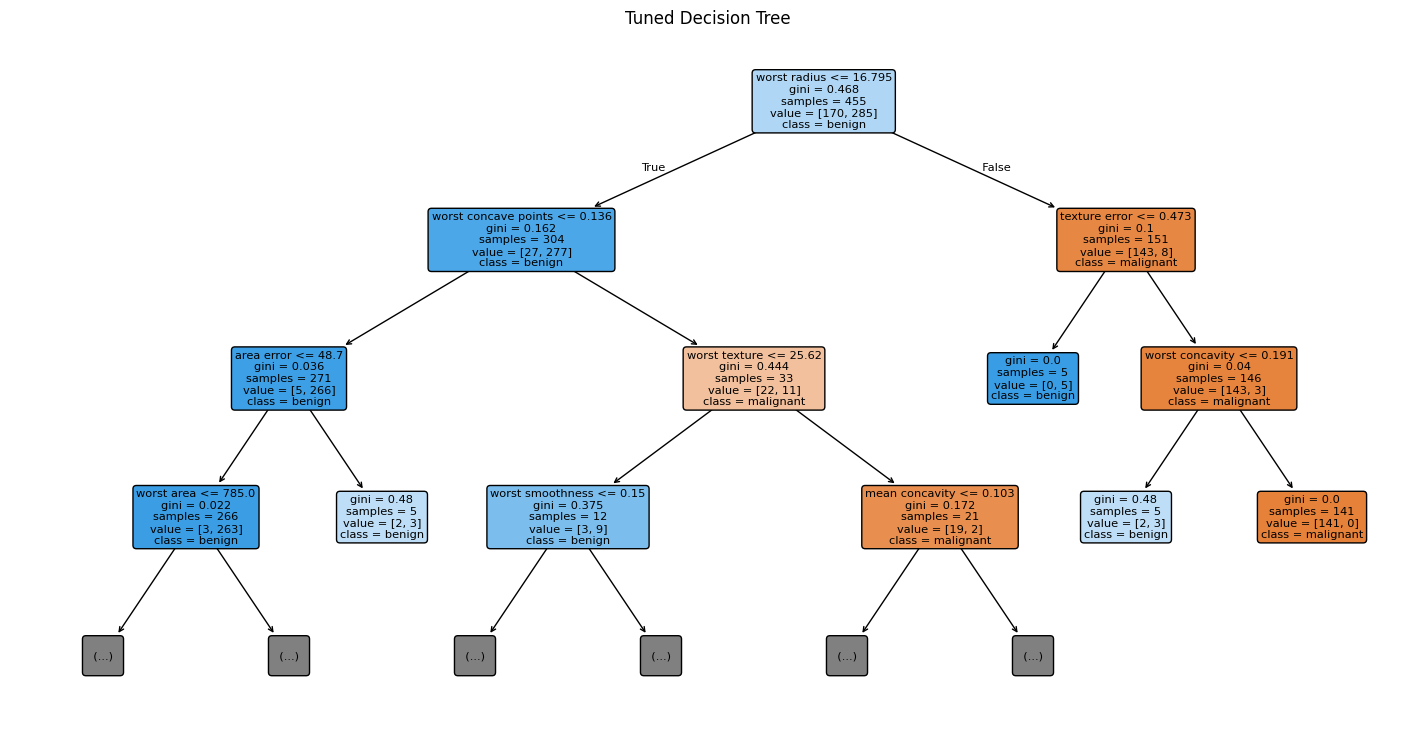

In [35]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 9))

plot_tree(
    dt_grid_search.best_estimator_,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Tuned Decision Tree")
plt.show()

# 10. Random Forest Feature Importance

Now connect back to the theory.

Each tree contributes impurity reductions.

The forest aggregates those contributions.

`feature_importances_` gives us an overall ranking.

**Reminder:** this is predictive/model importance, not causal importance.


In [36]:
rf_best = rf_grid_search.best_estimator_

importance = pd.Series(
    rf_best.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15)

,0
worst area,0.139165
worst concave points,0.127585
worst radius,0.098890
mean concave points,0.090850
worst perimeter,0.071547
mean perimeter,0.069706
mean radius,0.068590
mean concavity,0.058346
mean area,0.050297
worst concavity,0.034600


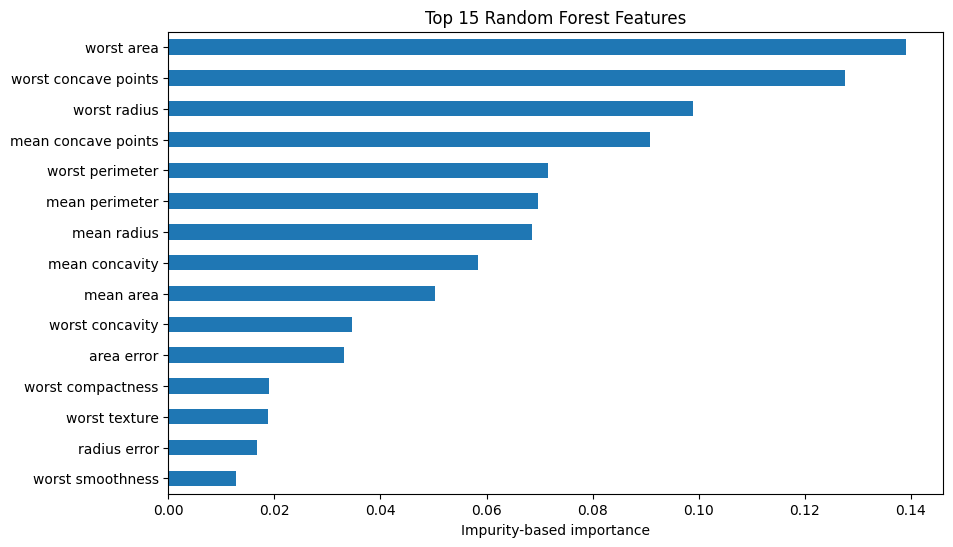

In [37]:
plt.figure(figsize=(10, 6))

importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Impurity-based importance")
plt.title("Top 15 Random Forest Features")
plt.show()

# 11. One new prediction

Finally, use the tuned Random Forest to predict one unseen observation.

Because this dataset has 30 features, we will simply take one test observation as the example.


In [38]:
one_customer = X_test.iloc[[0]]

prediction = rf_best.predict(one_customer)[0]
probability = rf_best.predict_proba(one_customer)[0, 1]

print("Actual class:", y_test.iloc[0])
print("Predicted class:", prediction)
print("Probability of class 1 (benign):", round(probability, 3))

Actual class: 0
Predicted class: 0
Probability of class 1 (benign): 0.0



## Decision Tree

```text
Training data
      ↓
Find best split
      ↓
Split recursively
      ↓
One tree
```

Potential problem:

> A tree can be sensitive to the training sample → high variance.

---

## Bagging

```text
Training data
      ↓
Bootstrap samples
      ↓
Tree 1   Tree 2   Tree 3 ... Tree B
      ↓      ↓       ↓
      └──────┴───────┴──────→ Aggregate
```

Main idea:

> Average / vote across different trees to reduce variance.

---

## Random Forest

Adds another source of randomness:

```text
Bootstrap rows
        +
Random feature subset at EACH NODE
        ↓
Less correlated trees
        ↓
Aggregate predictions
        ↓
Variance reduction
```

---

## GridSearchCV

```text
Small parameter grid
        ↓
Every combination
        ↓
5-fold CV for every combination
        ↓
Average validation score
        ↓
Best combination
        ↓
Fit best estimator on all training data
        ↓
Final test evaluation
```

### Key interview point

**Random Forest does NOT randomly choose the final split.**

At a node:

```text
Randomly select candidate features
            ↓
Find the best split among those features
            ↓
Use that best split
```

### Key validation point

**Never tune based on the test set.**

```text
Training data
    ↓
5-fold CV → hyperparameter selection
    ↓
Best model
    ↓
Test set → final unbiased-ish estimate
```
